# Análisis Exploratorio de Datos (EDA)
## Cybersecurity Threat Severity and Impact Classification

**Proyecto de Aula — Modelos y Simulación de Sistemas II**
Departamento de Ingeniería de Sistemas, Universidad de Antioquia

Este notebook realiza el análisis exploratorio de datos (EDA) correspondiente al Entregable I del proyecto,
usando la base de datos [*Global Cybersecurity Threats (2015–2024)*](https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-2024/data)
de Atharva Soundankar (Kaggle).

**Contenido:**
1. Carga de datos
2. Inspección general (dimensiones, tipos, nulos, duplicados)
3. Estadística descriptiva de variables numéricas
4. Distribución de variables numéricas
5. Distribución de variables categóricas
6. Relaciones entre variables (correlación, boxplots)
7. Construcción de la variable objetivo de severidad (terciles)
8. Imputación de datos faltantes
9. Codificación de variables (One-Hot + Z-score)
10. Conclusiones del EDA


## 1. Carga de librerías y del dataset

In [3]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# --------------------------------------------------------------------
# Carga del dataset: primero se intenta con kagglehub (descarga automática);
# si no está instalado o falla, se usa una ruta local manual como respaldo.
# --------------------------------------------------------------------

# Opción A: ruta local
MANUAL_DATA_PATH = "data/Global_Cybersecurity_Threats_2015-2024.csv"

df = None

try:
    import kagglehub

    dataset_dir = kagglehub.dataset_download(
        "atharvasoundankar/global-cybersecurity-threats-2015-2024"
    )
    print("Dataset descargado por kagglehub en:", dataset_dir)

    csv_files = glob.glob(os.path.join(dataset_dir, "*.csv"))
    if csv_files:
        DATA_PATH = csv_files[0]
        print("Archivo CSV encontrado:", DATA_PATH)
        df = pd.read_csv(DATA_PATH)
    else:
        print("kagglehub descargó la carpeta pero no se encontró ningún .csv dentro.")
except ModuleNotFoundError:
    print("kagglehub no está instalado (pip install kagglehub). Se usará la ruta manual.")
except Exception as e:
    print(f"No se pudo descargar con kagglehub ({e}). Se usará la ruta manual.")

if df is None:
    if os.path.exists(MANUAL_DATA_PATH):
        print("Cargando dataset desde ruta manual:", MANUAL_DATA_PATH)
        df = pd.read_csv(MANUAL_DATA_PATH)
    else:
        raise FileNotFoundError(
            "No se encontró el dataset. Opciones:\n"
            "  1) Instala kagglehub ('pip install kagglehub') y vuelve a correr esta celda, o\n"
            f"  2) Descarga el CSV manualmente desde Kaggle y colócalo en: {MANUAL_DATA_PATH}\n"
            "     (crea la carpeta 'data/' junto a este notebook si no existe)."
        )

print(f"\nDimensiones del dataset: {df.shape}")
df.head()


100%|██████████| 47.0k/47.0k [00:00<00:00, 135kB/s]

Extracting files...
Dataset descargado por kagglehub en: C:\Users\Usuario\.cache\kagglehub\datasets\atharvasoundankar\global-cybersecurity-threats-2015-2024\versions\1
Archivo CSV encontrado: C:\Users\Usuario\.cache\kagglehub\datasets\atharvasoundankar\global-cybersecurity-threats-2015-2024\versions\1\Global_Cybersecurity_Threats_2015-2024.csv

Dimensiones del dataset: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


## 2. Inspección general

Verificamos dimensiones, tipos de dato, nombres de columnas, duplicados y valores nulos,
tal como se describe en la Sección 1.B del reporte (composición de la base de datos).

In [4]:
print(f"Número de muestras (N): {df.shape[0]}")
print(f"Número de variables (D): {df.shape[1]}")
print()
df.info()


Número de muestras (N): 3000
Número de variables (D): 10

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234

In [5]:
# Normalizar nombres de columnas por si vienen con espacios/paréntesis distintos
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


In [6]:
# Duplicados
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")

# Valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "% nulos": pct_nulos})
resumen_nulos


Filas duplicadas: 0


,nulos,% nulos
Country,0,0.0
Year,0,0.0
Attack Type,0,0.0
Target Industry,0,0.0
Financial Loss (in Million $),0,0.0
Number of Affected Users,0,0.0
Attack Source,0,0.0
Security Vulnerability Type,0,0.0
Defense Mechanism Used,0,0.0
Incident Resolution Time (in Hours),0,0.0


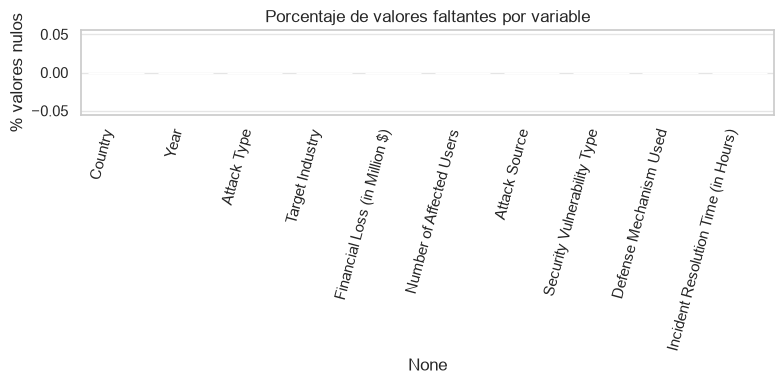

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=resumen_nulos.index, y=resumen_nulos["% nulos"], ax=ax, color="#4C72B0")
ax.set_ylabel("% valores nulos")
ax.set_title("Porcentaje de valores faltantes por variable")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 3. Estadística descriptiva de variables numéricas

Variables cuantitativas: `Financial Loss (in Million $)`, `Number of Affected Users`,
`Incident Resolution Time (in Hours)` y `Year`.

In [8]:
num_cols = [
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)",
    "Year",
]
num_cols = [c for c in num_cols if c in df.columns]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Financial Loss (in Million $),3000.0,50.492970,28.791415,0.5,25.7575,50.795,75.63,99.99
Number of Affected Users,3000.0,504684.136333,289944.084972,424.0,255805.2500,504513.000,758088.50,999635.00
Incident Resolution Time (in Hours),3000.0,36.476000,20.570768,1.0,19.0000,37.000,55.00,72.00
Year,3000.0,2019.570333,2.857932,2015.0,2017.0000,2020.000,2022.00,2024.00


## 4. Distribución de variables numéricas

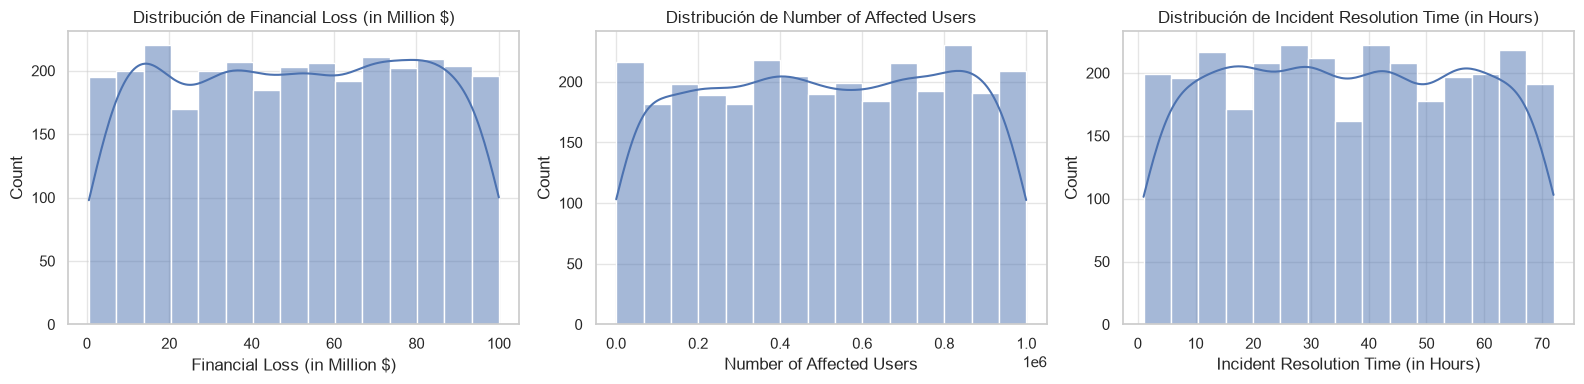

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dist_cols = [c for c in num_cols if c != "Year"]
for ax, col in zip(axes, dist_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


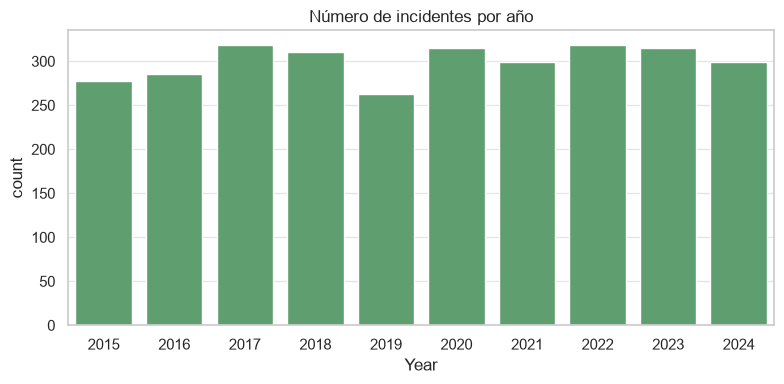

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x="Year", data=df, color="#55A868", ax=ax)
ax.set_title("Número de incidentes por año")
plt.tight_layout()
plt.show()


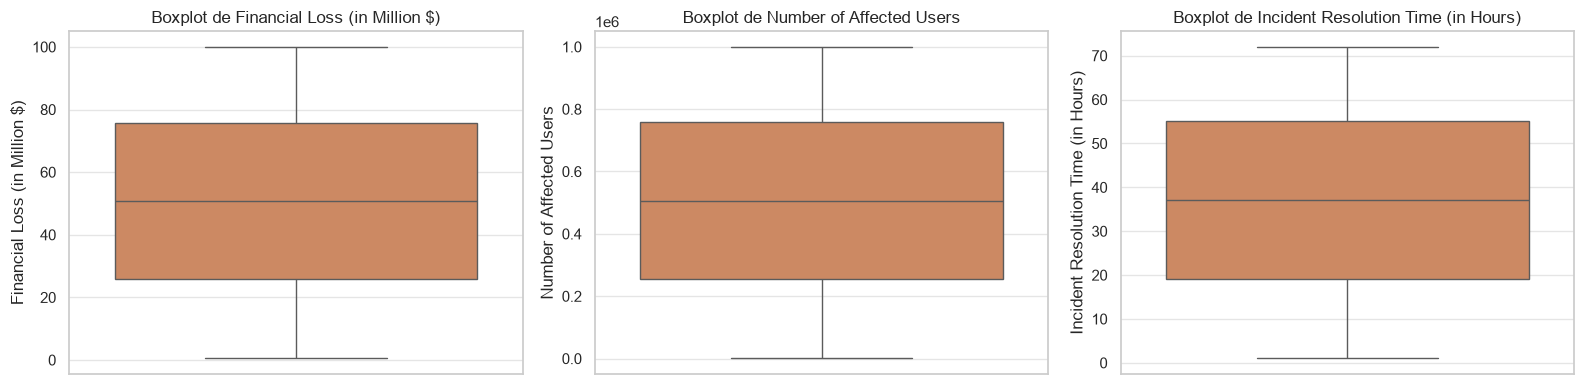

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, dist_cols):
    sns.boxplot(y=df[col], ax=ax, color="#DD8452")
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


## 5. Distribución de variables categóricas

Variables: `Country`, `Attack Type`, `Target Industry`, `Attack Source`,
`Security Vulnerability Type`, `Defense Mechanism Used`.

In [12]:
cat_cols = [
    "Country",
    "Attack Type",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used",
]
cat_cols = [c for c in cat_cols if c in df.columns]

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Country ---
Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

--- Attack Type ---
Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

--- Target Industry ---
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

--- Attack Source ---
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

--- Security Vulnerability Type ---
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: coun

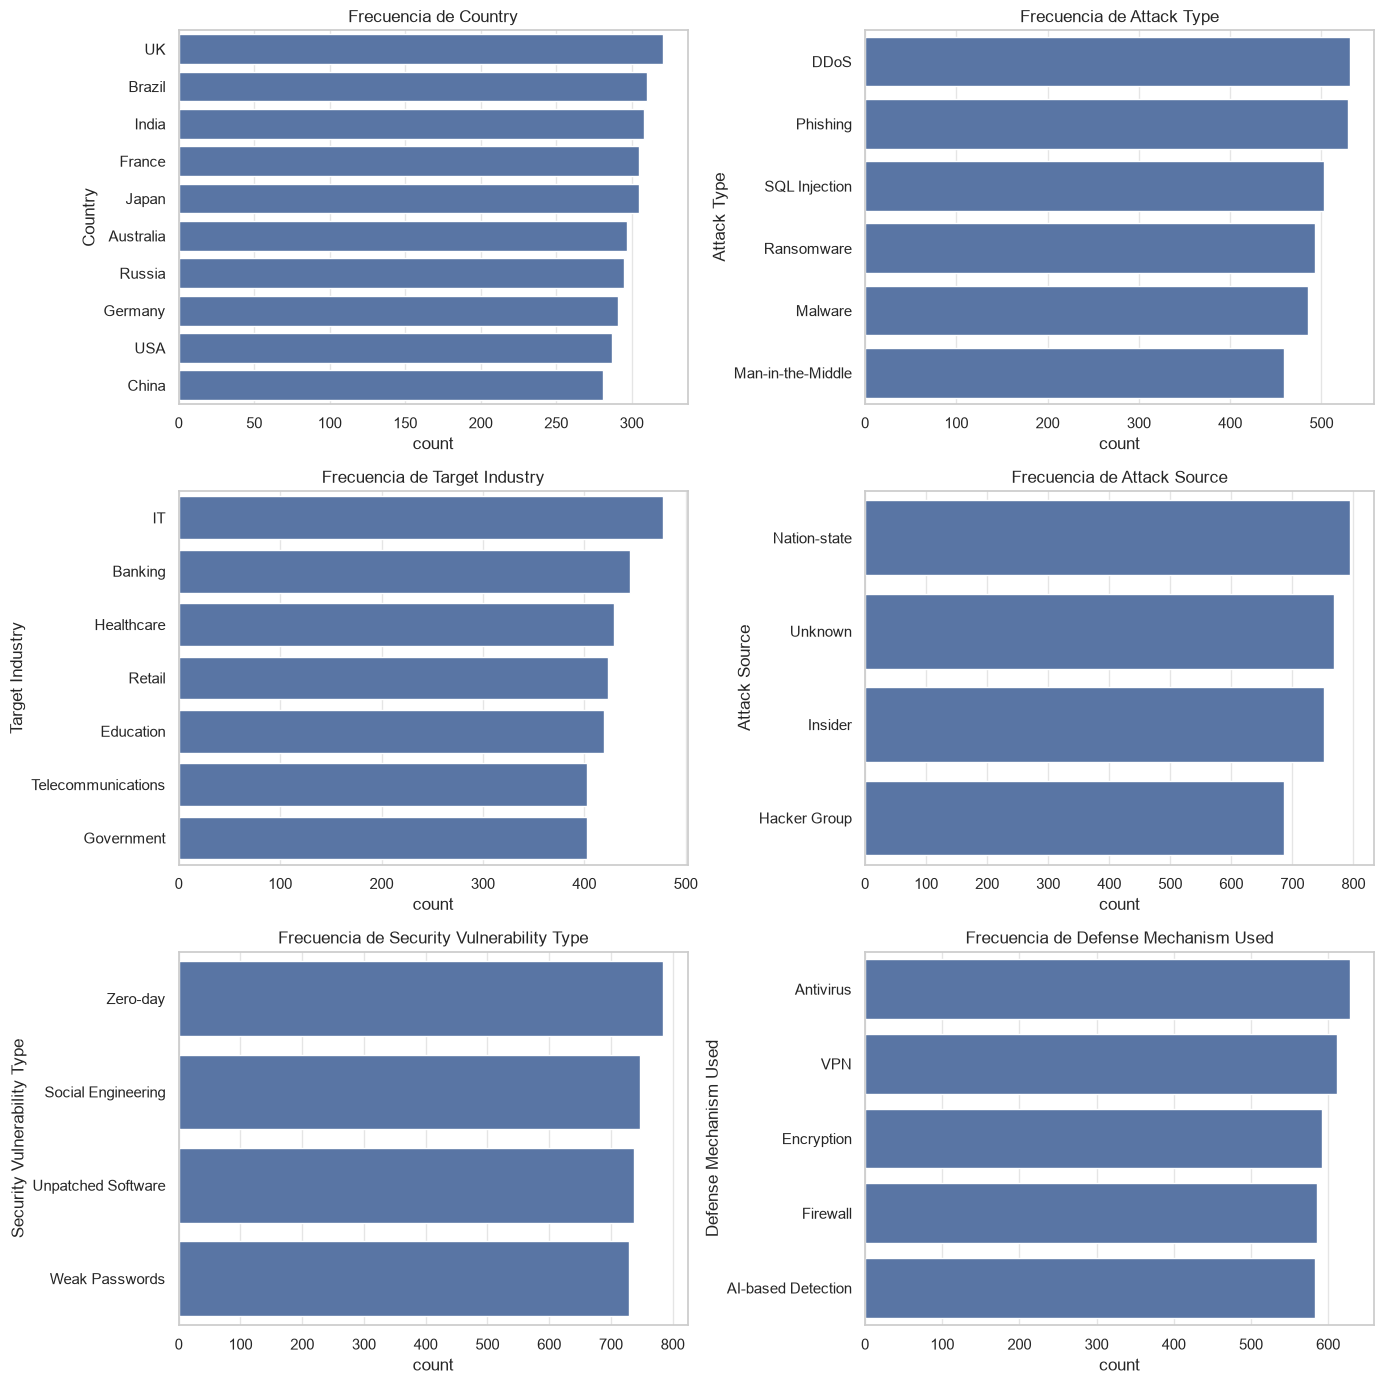

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"Frecuencia de {col}")
plt.tight_layout()
plt.show()


## 6. Relaciones entre variables

### 6.1 Matriz de correlación (variables numéricas)

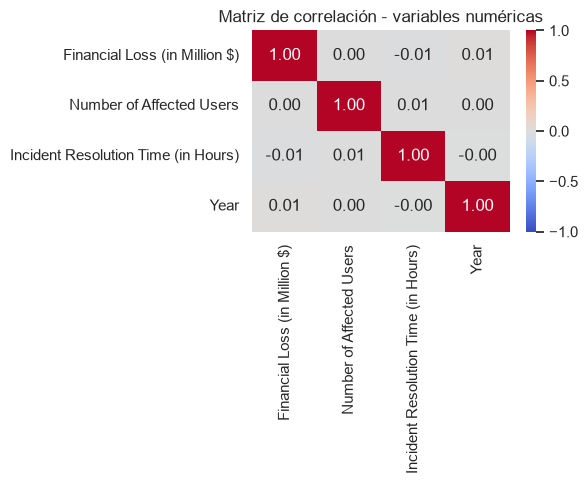

In [14]:
corr = df[num_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación - variables numéricas")
plt.tight_layout()
plt.show()


### 6.2 Pérdida financiera por tipo de ataque y por sector

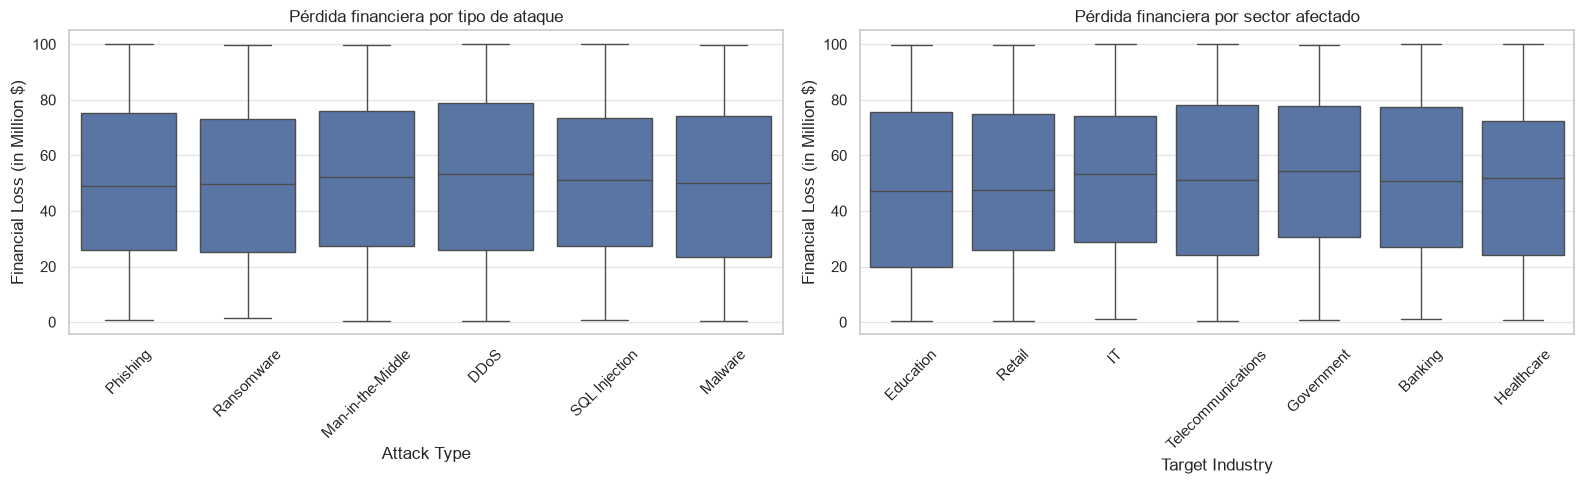

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x="Attack Type", y="Financial Loss (in Million $)", data=df, ax=axes[0])
axes[0].set_title("Pérdida financiera por tipo de ataque")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(x="Target Industry", y="Financial Loss (in Million $)", data=df, ax=axes[1])
axes[1].set_title("Pérdida financiera por sector afectado")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


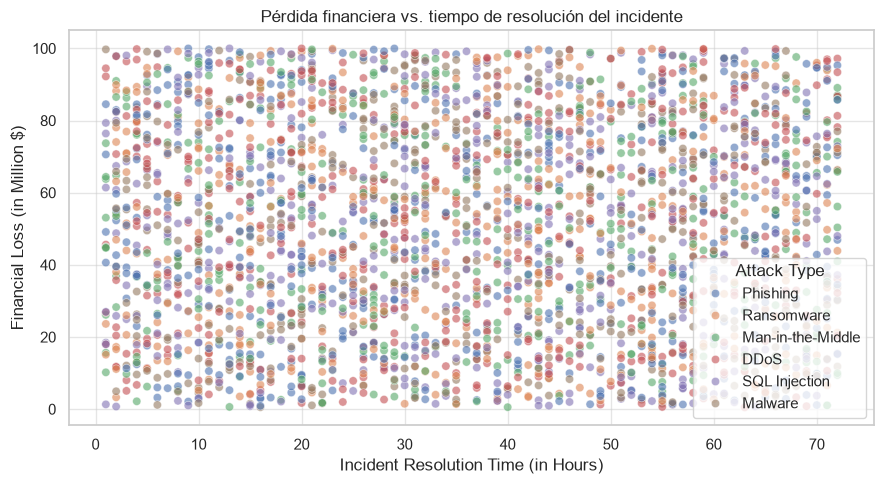

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    x="Incident Resolution Time (in Hours)",
    y="Financial Loss (in Million $)",
    hue="Attack Type",
    data=df,
    alpha=0.6,
    ax=ax,
)
ax.set_title("Pérdida financiera vs. tiempo de resolución del incidente")
plt.tight_layout()
plt.show()


## 7. Construcción de la variable objetivo de severidad

Siguiendo la Sección 1.C del reporte, se define la variable de severidad
$Y \in \{\text{Bajo}, \text{Medio}, \text{Alto}\}$ discretizando el impacto
combinado de `Financial Loss` y `Incident Resolution Time` mediante terciles.

Severity
Bajo     1000
Medio    1000
Alto     1000
Name: count, dtype: int64


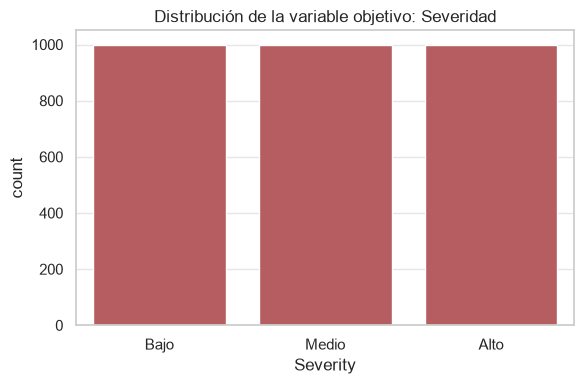

In [17]:
# Índice de impacto combinado (promedio de los rangos percentiles de ambas variables)
df["_rank_loss"] = df["Financial Loss (in Million $)"].rank(pct=True)
df["_rank_time"] = df["Incident Resolution Time (in Hours)"].rank(pct=True)
df["Impact_Score"] = (df["_rank_loss"] + df["_rank_time"]) / 2

df["Severity"] = pd.qcut(
    df["Impact_Score"], q=3, labels=["Bajo", "Medio", "Alto"]
)

df.drop(columns=["_rank_loss", "_rank_time"], inplace=True)

print(df["Severity"].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="Severity", data=df, order=["Bajo", "Medio", "Alto"], color="#C44E52", ax=ax)
ax.set_title("Distribución de la variable objetivo: Severidad")
plt.tight_layout()
plt.show()


## 8. Imputación de datos faltantes

Conforme a la estrategia descrita en el reporte: mediana para variables numéricas
y moda para variables categóricas. Esta celda se ejecuta de forma condicional
(solo actúa si existen valores nulos).

In [18]:
df_imputed = df.copy()

for col in num_cols:
    if df_imputed[col].isnull().sum() > 0:
        mediana = df_imputed[col].median()
        df_imputed[col] = df_imputed[col].fillna(mediana)
        print(f"Imputado '{col}' con la mediana = {mediana:.2f}")

for col in cat_cols:
    if df_imputed[col].isnull().sum() > 0:
        moda = df_imputed[col].mode()[0]
        df_imputed[col] = df_imputed[col].fillna(moda)
        print(f"Imputado '{col}' con la moda = {moda}")

print()
print("Valores nulos restantes:", df_imputed.isnull().sum().sum())



Valores nulos restantes: 0


## 9. Codificación de variables

- **One-Hot Encoding** para variables categóricas nominales.
- **Estandarización Z-score** (`StandardScaler`) para variables numéricas continuas/discretas.

In [19]:
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df_imputed, columns=cat_cols, drop_first=False)

scaler = StandardScaler()
scale_cols = [c for c in num_cols if c != "Year"] + ["Year"]
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print(f"Dimensiones tras codificación: {df_encoded.shape}")
df_encoded.head()


Dimensiones tras codificación: (3000, 42)


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours),Impact_Score,Severity,Country_Australia,Country_Brazil,Country_China,Country_France,...,Attack Source_Unknown,Security Vulnerability Type_Social Engineering,Security Vulnerability Type_Unpatched Software,Security Vulnerability Type_Weak Passwords,Security Vulnerability Type_Zero-day,Defense Mechanism Used_AI-based Detection,Defense Mechanism Used_Antivirus,Defense Mechanism Used_Encryption,Defense Mechanism Used_Firewall,Defense Mechanism Used_VPN
0,-0.199595,1.043437,0.926143,1.289617,0.837000,Alto,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
1,-0.199595,0.406336,-0.719994,1.678584,0.795917,Alto,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
2,-0.899518,-0.411405,0.349128,-0.801076,0.324750,Bajo,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,1.550214,-0.314485,0.533419,-1.433146,0.246917,Bajo,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,-0.549556,0.830839,1.055544,1.532721,0.840833,Alto,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True


## 10. Conclusiones del EDA

- La base de datos contiene 3.000 registros y 10 variables, sin un porcentaje relevante de valores nulos.
- Las variables numéricas (`Financial Loss`, `Number of Affected Users`, `Incident Resolution Time`)
  presentan distribuciones relativamente dispersas, sin una tendencia temporal marcada por año.
- No se observan correlaciones lineales fuertes entre las variables numéricas, lo que sugiere que
  la severidad del incidente depende de una combinación de factores categóricos (tipo de ataque,
  sector, vulnerabilidad) más que de una única variable numérica.
- La variable de severidad construida por terciles (`Bajo`, `Medio`, `Alto`) queda balanceada,
  lo cual es adecuado para el entrenamiento de un clasificador multiclase.
- Estos hallazgos respaldan el paradigma de aprendizaje supervisado (clasificación multiclase +
  regresión) propuesto en la Sección 1.C del reporte.